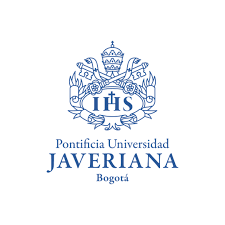

***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Sara Mejia Giraldo

Fecha de Inicio: 14/04/2026

Fecha actual: 28/04/2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar modelos de predicción utilizando la biblioteca de aprendizaje automático MLlib PySpark, con el fin de explorar y aplicar técnicas de IA en entornos de procesamiento con alto volúmen de datos.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.-  Análisis y Preparación de Datos.

3.- Análisis Exploratorio de los Parámetros de Calidad del Agua.

4.- Clasificación de la Calidad del Agua Mediante Rangos por Variable

5.- Construcción del Índice de Calidad del Agua (ICA)

6.- Visualización de Estados de la India

7.- Predicción del Índice de Calidad del Agua mediante Redes Neuronales

  - Evaluación del Modelo Predictivo: Con métricas ampliamente empleadas en problemas de regresión: RMSE, MAE y R². Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1. Importación de bibliotecas**

En esta sección se realizó la importación de las bibliotecas necesarias para el desarrollo del cuaderno, incluyendo la configuración de variables de entorno mediante pip y la inicialización de la sesión de PySpark. El levantamiento de la sesión Spark fue fundamental, ya que permitió la conexión y acceso a los datos almacenados en Hadoop, así como el uso del motor de procesamiento distribuido.    

### **1.1. Levantamiento de variables de entorno pip**

In [1]:
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

### **1.2. Levantamiento de sesión SPARK**

Se trabajó con DataFrames de Spark, una estructura de datos optimizada que facilita tareas de exploración, limpieza, transformación y análisis de grandes volúmenes de información de forma eficiente, aprovechando los recursos del clúster y mejorando el rendimiento frente a métodos tradicionales.

In [2]:
configura = SparkConf()

configura.setAppName("Calidad_Agua_Mejia")

sparkMejia = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkMejia.sparkContext, sparkSession=sparkMejia)

sparkContextoMejia = sparkMejia.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkMejia

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 18:11:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


### **1.3. Carga de Datos desde el HADOOP HDFS**

Hadoop Distributed File System (HDFS) es el sistema de archivos distribuido de Apache Hadoop. Está diseñado para almacenar grandes volúmenes de datos en varias máquinas de un clúster de forma simultánea. Se destaca por su alta tolerancia a fallos y por su escalabilidad.

A continuación, se utiliza Apache Spark para leer el archivo en formato CSV almacenado en HDFS y cargarlo en un DataFrame de Spark.

In [3]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkMejia.read.format("csv").option("header", "true").load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

df00.show(5)

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


[Stage 1:>                                                          (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **2. Análisis y Preparación de Datos**

#### Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación.
- Columnas: conocimiento de las columnas, eliminación.
- Estadisticos Descriptivos.
- Análisis de datos nulos o imposibles: concimiento.
- Continuación EDA

### 2.1. Tipos de datos: coherencia de tipo de datos, transformacion
Para garantizar la calidad y consistencia de la base de datos, se realizó una revisión y ajuste de los tipos de datos de cada variable.

### 2.1.1. Revisión inicial de la estructura:
Mediante la función printSchema() de Apache Spark se inspeccionó el esquema inicial del DataFrame. En esta primera validación se identificó que todas las columnas habían sido cargadas como tipo string.

In [4]:
df00.printSchema()

root
 |-- STATION CODE: string (nullable = true)
 |-- LOCATIONS: string (nullable = true)
 |-- STATE: string (nullable = true)
 |-- TEMP: string (nullable = true)
 |-- DO: string (nullable = true)
 |-- pH: string (nullable = true)
 |-- CONDUCTIVITY: string (nullable = true)
 |-- BOD: string (nullable = true)
 |-- NITRATE_N_NITRITE_N: string (nullable = true)
 |-- FECAL_COLIFORM: string (nullable = true)
 |-- TOTAL_COLIFORM: string (nullable = true)



### 2.1.2. Definición de tipos esperados:
Con base en la naturaleza de cada variable, se determinó la estructura correcta de los datos:
- STATION CODE, CONDUCTIVITY, FECAL_COLIFORM, TOTAL_COLIFORM enteros.
- TEMP, DO, pH, BOD, NITRATE_N_NITRITE_N flotantes
- LOCATIONS y STATE cadenas de texto

### 2.1.3. Transformación de variables:
Posteriormente, se cambio el nombre de una de las variables. Luego, se aplicó el proceso de casting o conversión de tipos de datos, asignando a cada columna el formato correspondiente. Esto permitió dejar la base preparada para análisis estadísticos, cálculos numéricos y validaciones posteriores, evitando errores derivados de trabajar variables numéricas como texto.

In [5]:
# se cambia el nombre de la columna, al reemplazar el espacio por un guin bajo (_)
df01 = df00.withColumnRenamed('STATION CODE', 'STATION_CODE')

In [6]:
# se hace la conversion de string a int
df02 = df01.withColumn("STATION_CODE", df01.STATION_CODE.cast("int"))
df02 = df02.withColumn("CONDUCTIVITY", df02.CONDUCTIVITY.cast("int"))
df02 = df02.withColumn("FECAL_COLIFORM", df02.FECAL_COLIFORM.cast("int"))
df02 = df02.withColumn("TOTAL_COLIFORM", df02.TOTAL_COLIFORM.cast("int"))

df02.printSchema()

root
 |-- STATION_CODE: integer (nullable = true)
 |-- LOCATIONS: string (nullable = true)
 |-- STATE: string (nullable = true)
 |-- TEMP: string (nullable = true)
 |-- DO: string (nullable = true)
 |-- pH: string (nullable = true)
 |-- CONDUCTIVITY: integer (nullable = true)
 |-- BOD: string (nullable = true)
 |-- NITRATE_N_NITRITE_N: string (nullable = true)
 |-- FECAL_COLIFORM: integer (nullable = true)
 |-- TOTAL_COLIFORM: integer (nullable = true)



In [7]:
# se hace la conversion de string a double
df03 = df02.withColumn("TEMP", df02.TEMP.cast("double"))
df03 = df03.withColumn("DO", df02.DO.cast("double"))
df03 = df03.withColumn("pH", df02.pH.cast("double"))
df03 = df03.withColumn("BOD", df02.BOD.cast("double"))
df03 = df03.withColumn("NITRATE_N_NITRITE_N", df02.NITRATE_N_NITRITE_N.cast("double"))
df03.printSchema()

root
 |-- STATION_CODE: integer (nullable = true)
 |-- LOCATIONS: string (nullable = true)
 |-- STATE: string (nullable = true)
 |-- TEMP: double (nullable = true)
 |-- DO: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- CONDUCTIVITY: integer (nullable = true)
 |-- BOD: double (nullable = true)
 |-- NITRATE_N_NITRITE_N: double (nullable = true)
 |-- FECAL_COLIFORM: integer (nullable = true)
 |-- TOTAL_COLIFORM: integer (nullable = true)



### 2.2. Columnas: conocimiento de las columnas, eliminación
Se revisan las columnas del dataframe, su definición y se eliminan aquellas columnas que no son útiles en este análisis, dependiendo de los objetivos establecidos inicialmente. 

In [8]:
# Conocimiento de las columnas
df03.columns

['STATION_CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

In [9]:
# se elimina la columna TOTAL_COLIFORM pues no aporta al estudio
df04 = df03.drop("TOTAL_COLIFORM")
df04.columns

['STATION_CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

### 2.3. Estadisticas Descriptivas
El análisis se desarrolló en dos etapas exploratorias. Inicialmente, se realizó una revisión preliminar mediante estadísticos descriptivos y diagramas de caja y bigotes, con el fin de identificar valores atípicos, dispersión y posibles inconsistencias en las variables. Posteriormente, se llevó a cabo el proceso de limpieza y transformación de datos, incluyendo tratamiento de valores faltantes y ajuste de tipos de datos. Finalmente, con la base depurada, se efectuaron visualizaciones complementarias como histogramas y otros gráficos para analizar la distribución y comportamiento de las variables.

In [10]:
for valor in df04.columns:
  
  df04.describe([valor]).show()

+-------+-----------------+
|summary|     STATION_CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|               11|
|    max|             3330|
+-------+-----------------+



+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+



+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               529|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|              33.8|
+-------+------------------+

+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              532|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|              0.0|
|    max|             16.3|
+-------+-----------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|               6.3|
|    max|              14.7|
+-------+------------------

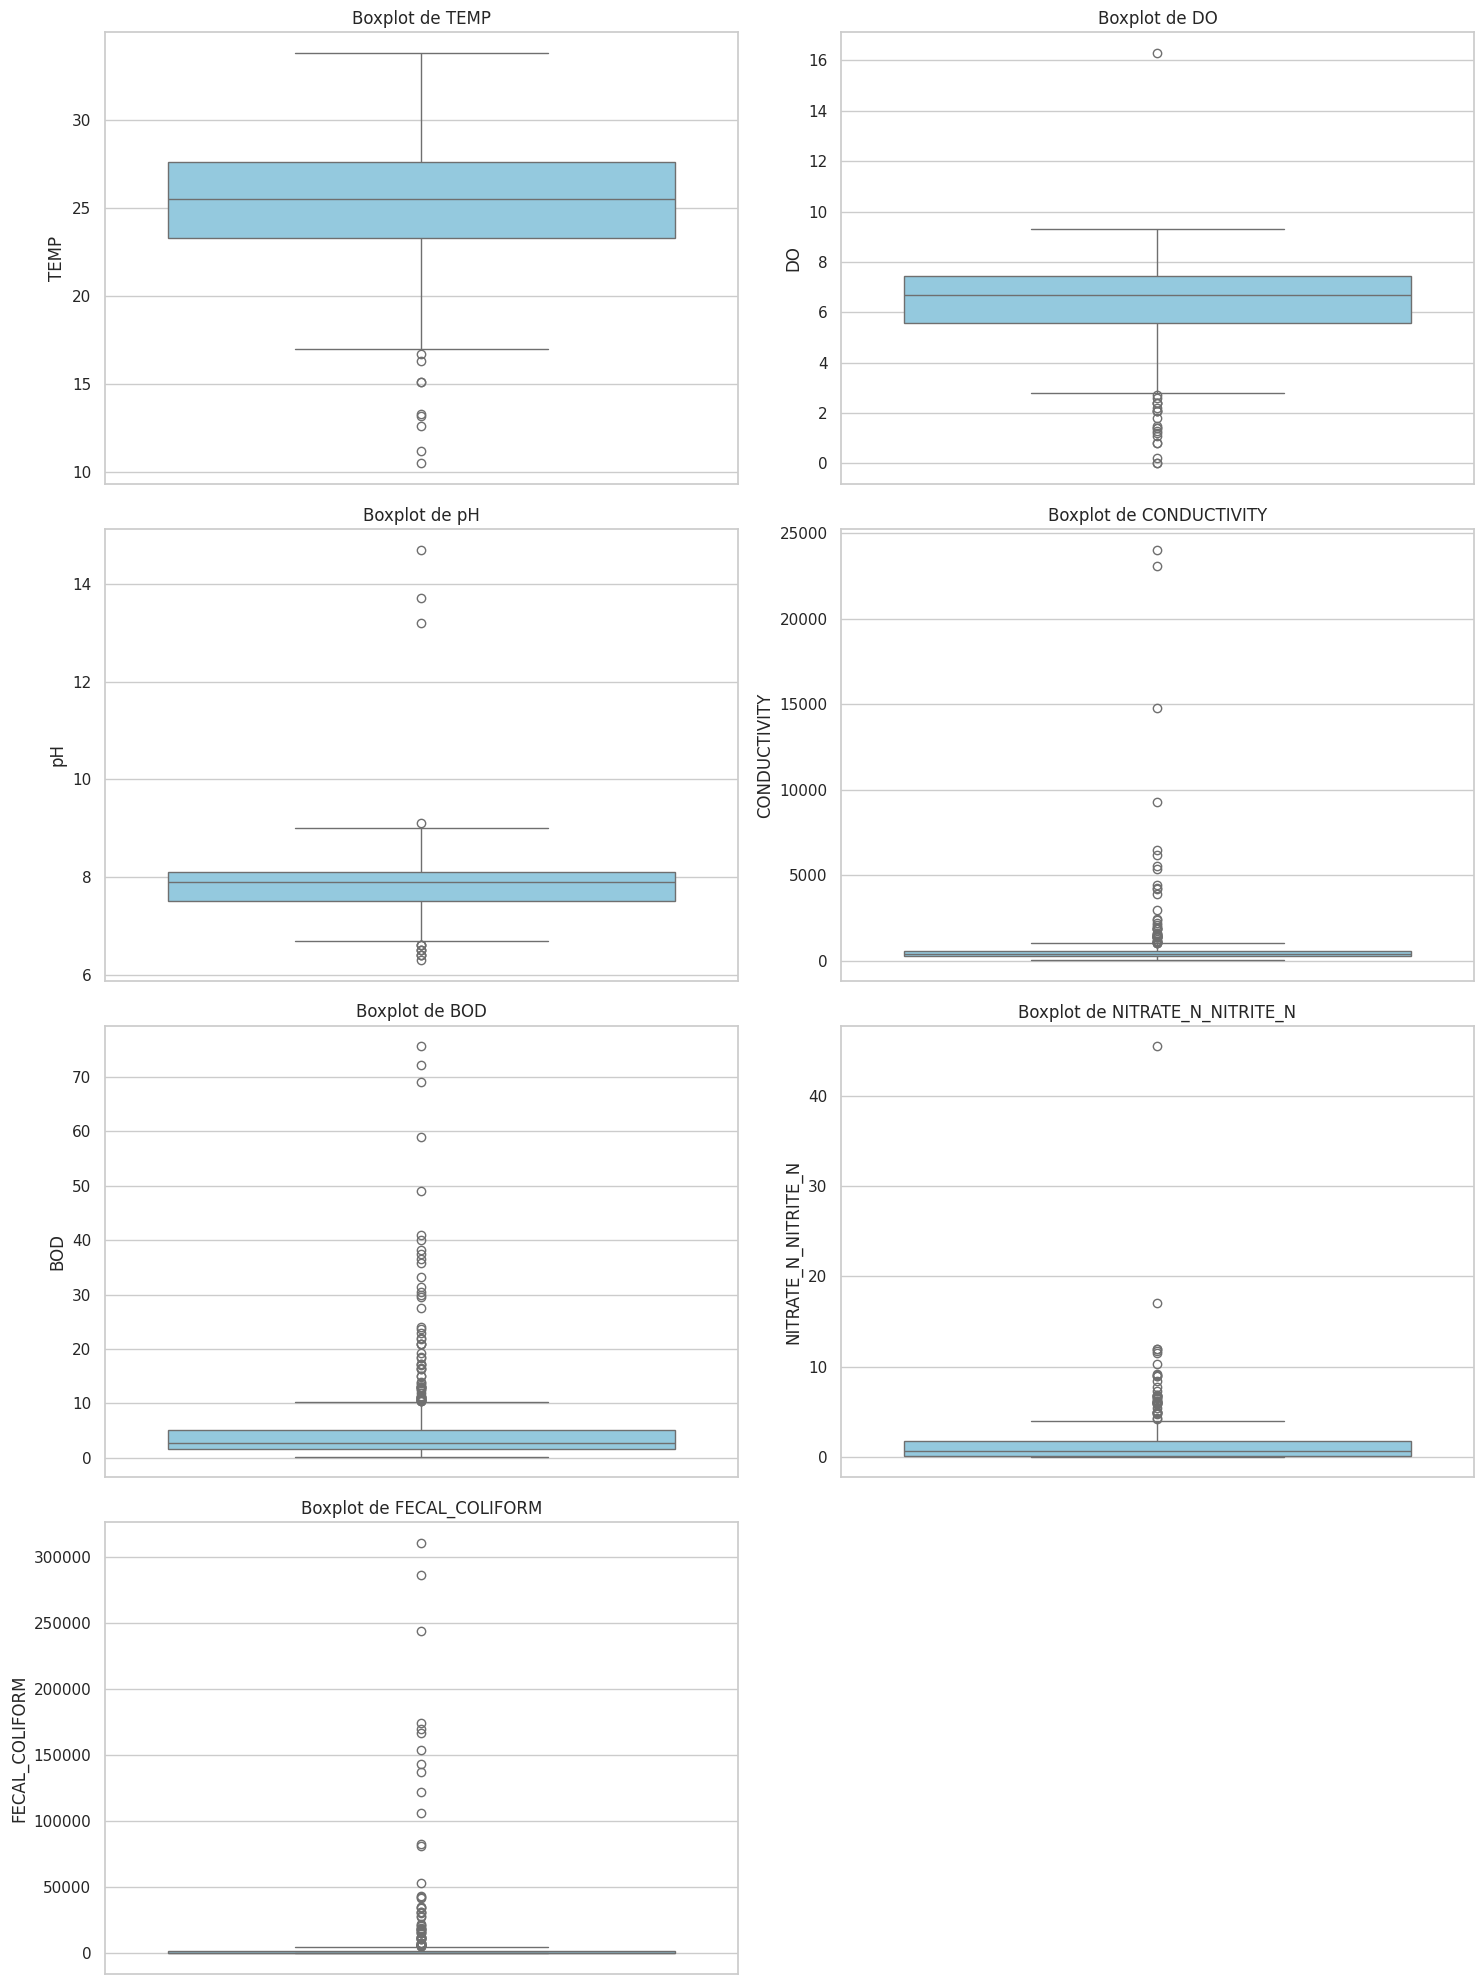

In [11]:
# Lista de variables numéricas para boxplots
variables = [
    "TEMP",
    "DO",
    "pH",
    "CONDUCTIVITY",
    "BOD",
    "NITRATE_N_NITRITE_N",
    "FECAL_COLIFORM"
]

# Pasar de PySpark a pandas (solo columnas necesarias)
df_pandas = df04.select(variables).toPandas()

# Configuración visual
sns.set(style="whitegrid")
plt.figure(figsize=(15,20))

# Boxplots con FOR
for i, var in enumerate(variables, 1):
    plt.subplot(4,2,i)
    sns.boxplot(y=df_pandas[var], color="skyblue")
    plt.title(f"Boxplot de {var}")
    plt.ylabel(var)

plt.tight_layout()
plt.show()

#### Observaciones:
A partir de los estadísticos descriptivos y los gráficos de cajas y bigotes de las variables TEMP, DO, pH, CONDUCTIVITY, BOD, NITRATE_N_NITRITE_N y FECAL_COLIFORM, se evidencia la presencia de valores atípicos en todas las variables analizadas. Esto indica que existen registros que se alejan considerablemente del comportamiento general de los datos.

Además, se observa que varias variables no presentan una distribución simétrica, especialmente CONDUCTIVITY, BOD, NITRATE_N_NITRITE_N y FECAL_COLIFORM, donde la mayoría de los datos se concentran en valores bajos, pero aparecen algunos registros extremadamente altos. Por esta razón, la media puede verse afectada por estos valores extremos y no representar adecuadamente el comportamiento típico de la variable.

También se identifica que variables como FECAL_COLIFORM, BOD y CONDUCTIVITY presentan una alta dispersión, esto podria significar diferencias importantes en la calidad del agua entre estaciones o ubicaciones. Pero, más adelante se hara el análisis necesario para aceptar o rechazar esta hipotesis. 

### 2.4. Visualización de los DATOS NULOS

In [12]:
df04.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df04.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|STATION_CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|           0|        0|    0|   5|  2|  0|          30|  6|                  2|            82|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+



In [13]:
filas_con_faltantes = df04.select(
    F.count(
        F.when(
            sum(F.col(c).isNull().cast("int") for c in df04.columns) > 0,
            1
        )
    ).alias("filas_con_faltantes")
)

filas_con_faltantes.show()

/tmp/ipykernel_3891514/458049764.py:4: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sum(F.col(c).isNull().cast("int") for c in df04.columns) > 0,


+-------------------+
|filas_con_faltantes|
+-------------------+
|                 87|
+-------------------+



In [14]:
print(f"REGISTROS ELIMINADOS")
print(f"Cantidad total de registros {df04.count()}")
print(f"Cantidad procentaje registros nulos {87*100/df04.count()} %")

REGISTROS ELIMINADOS
Cantidad total de registros 534
Cantidad procentaje registros nulos 16.292134831460675 %


### 2.4.1. Análisis Faltantes
#### Observaciones:
- Los valores nulos identificados corresponden a registros marcados como N/A en la fuente original.
- CONDUCTIVITY y FECAL_COLIFORM presentaron la mayor cantidad de valores faltantes.
- Ambas variables mostraron alta dispersión (desviación estándar elevada), lo cual sugiere presencia de variabilidad considerable y posibles valores extremos

#### Decisiones:
- Los valores faltantes de CONDUCTIVITY y FECAL_COLIFORM fueron reemplazados por la mediana general de cada variable.
- La mediana se eligió por ser una medida más resistente a valores atípicos y distribuciones sesgadas.
- Se decide imputarlos en lugar de eliminarlos, ya que si se eliminan las filas con registros faltantes antes de la imputacion se estaria eliminando alrededor del 16% del dataset.

#### Sugerencias
- En fases posteriores, si se detectan diferencias territoriales, temporales o por tipo de fuente, se recomienda evaluar una imputación por grupos homohéneos (municipio, zona, estación, periodo, etc.).

### 2.4.2. Imputacion de valores:

In [15]:
mediana = df04.approxQuantile("CONDUCTIVITY", [0.5], 0.01)[0]

# reemplazar nulos por la mediana
df05 = df04.withColumn(
    "CONDUCTIVITY",
    F.when(F.col("CONDUCTIVITY").isNull(), mediana)
    .otherwise(F.col("CONDUCTIVITY"))
)

In [16]:
mediana = df04.approxQuantile("FECAL_COLIFORM", [0.5], 0.01)[0]

# reemplazar nulos por la mediana
df06 = df05.withColumn(
    "FECAL_COLIFORM",
    F.when(F.col("FECAL_COLIFORM").isNull(), mediana)
    .otherwise(F.col("FECAL_COLIFORM"))
)

### 2.4.3. Eliminación de filas con registros faltantes

In [17]:
# Se crea una vista para ser usada en las visualizaciones
df06.createOrReplaceTempView("df00_sql")

In [18]:
df07 = sparkMejia.sql('''Select * from df00_sql where TEMP is not null and
  
             DO is not null and
  
             pH is not null and
  
             CONDUCTIVITY is not null and
  
             BOD is not null and
  
             NITRATE_N_NITRITE_N is not null and
  
             FECAL_COLIFORM is not null''')

In [19]:
restante = df06.count() - df07.count()
print(restante)

13


In [20]:
print(f"REGISTROS ELIMINADOS")
print(f"Cantidad total de registros {df07.count()}")
print(f"Cantidad procentaje registros nulos {13*100/df07.count()} %")

REGISTROS ELIMINADOS
Cantidad total de registros 521
Cantidad procentaje registros nulos 2.495201535508637 %


#### Resumen:
Se realizó la limpieza de datos. Los valores faltantes de CONDUCTIVITY y FECAL_COLIFORM fueron imputados utilizando la medianas. Después, se eliminaron las filas que aún contenían registros faltantes en otras variables, obteniendo así un conjunto de datos depurado y listo para continuar con un análisis más profundo de los datos.

## **3. Análisis Exploratorio de los Parámetros de Calidad del Agua**

In [21]:
#Se verifica la Cantidad de Valores Nulos o Imposibles
df07.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df07.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|STATION_CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+



In [22]:
df07.dtypes

[('STATION_CODE', 'int'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'double'),
 ('DO', 'double'),
 ('pH', 'double'),
 ('CONDUCTIVITY', 'double'),
 ('BOD', 'double'),
 ('NITRATE_N_NITRITE_N', 'double'),
 ('FECAL_COLIFORM', 'double')]

### 3.1. Distribución de los Parámetros

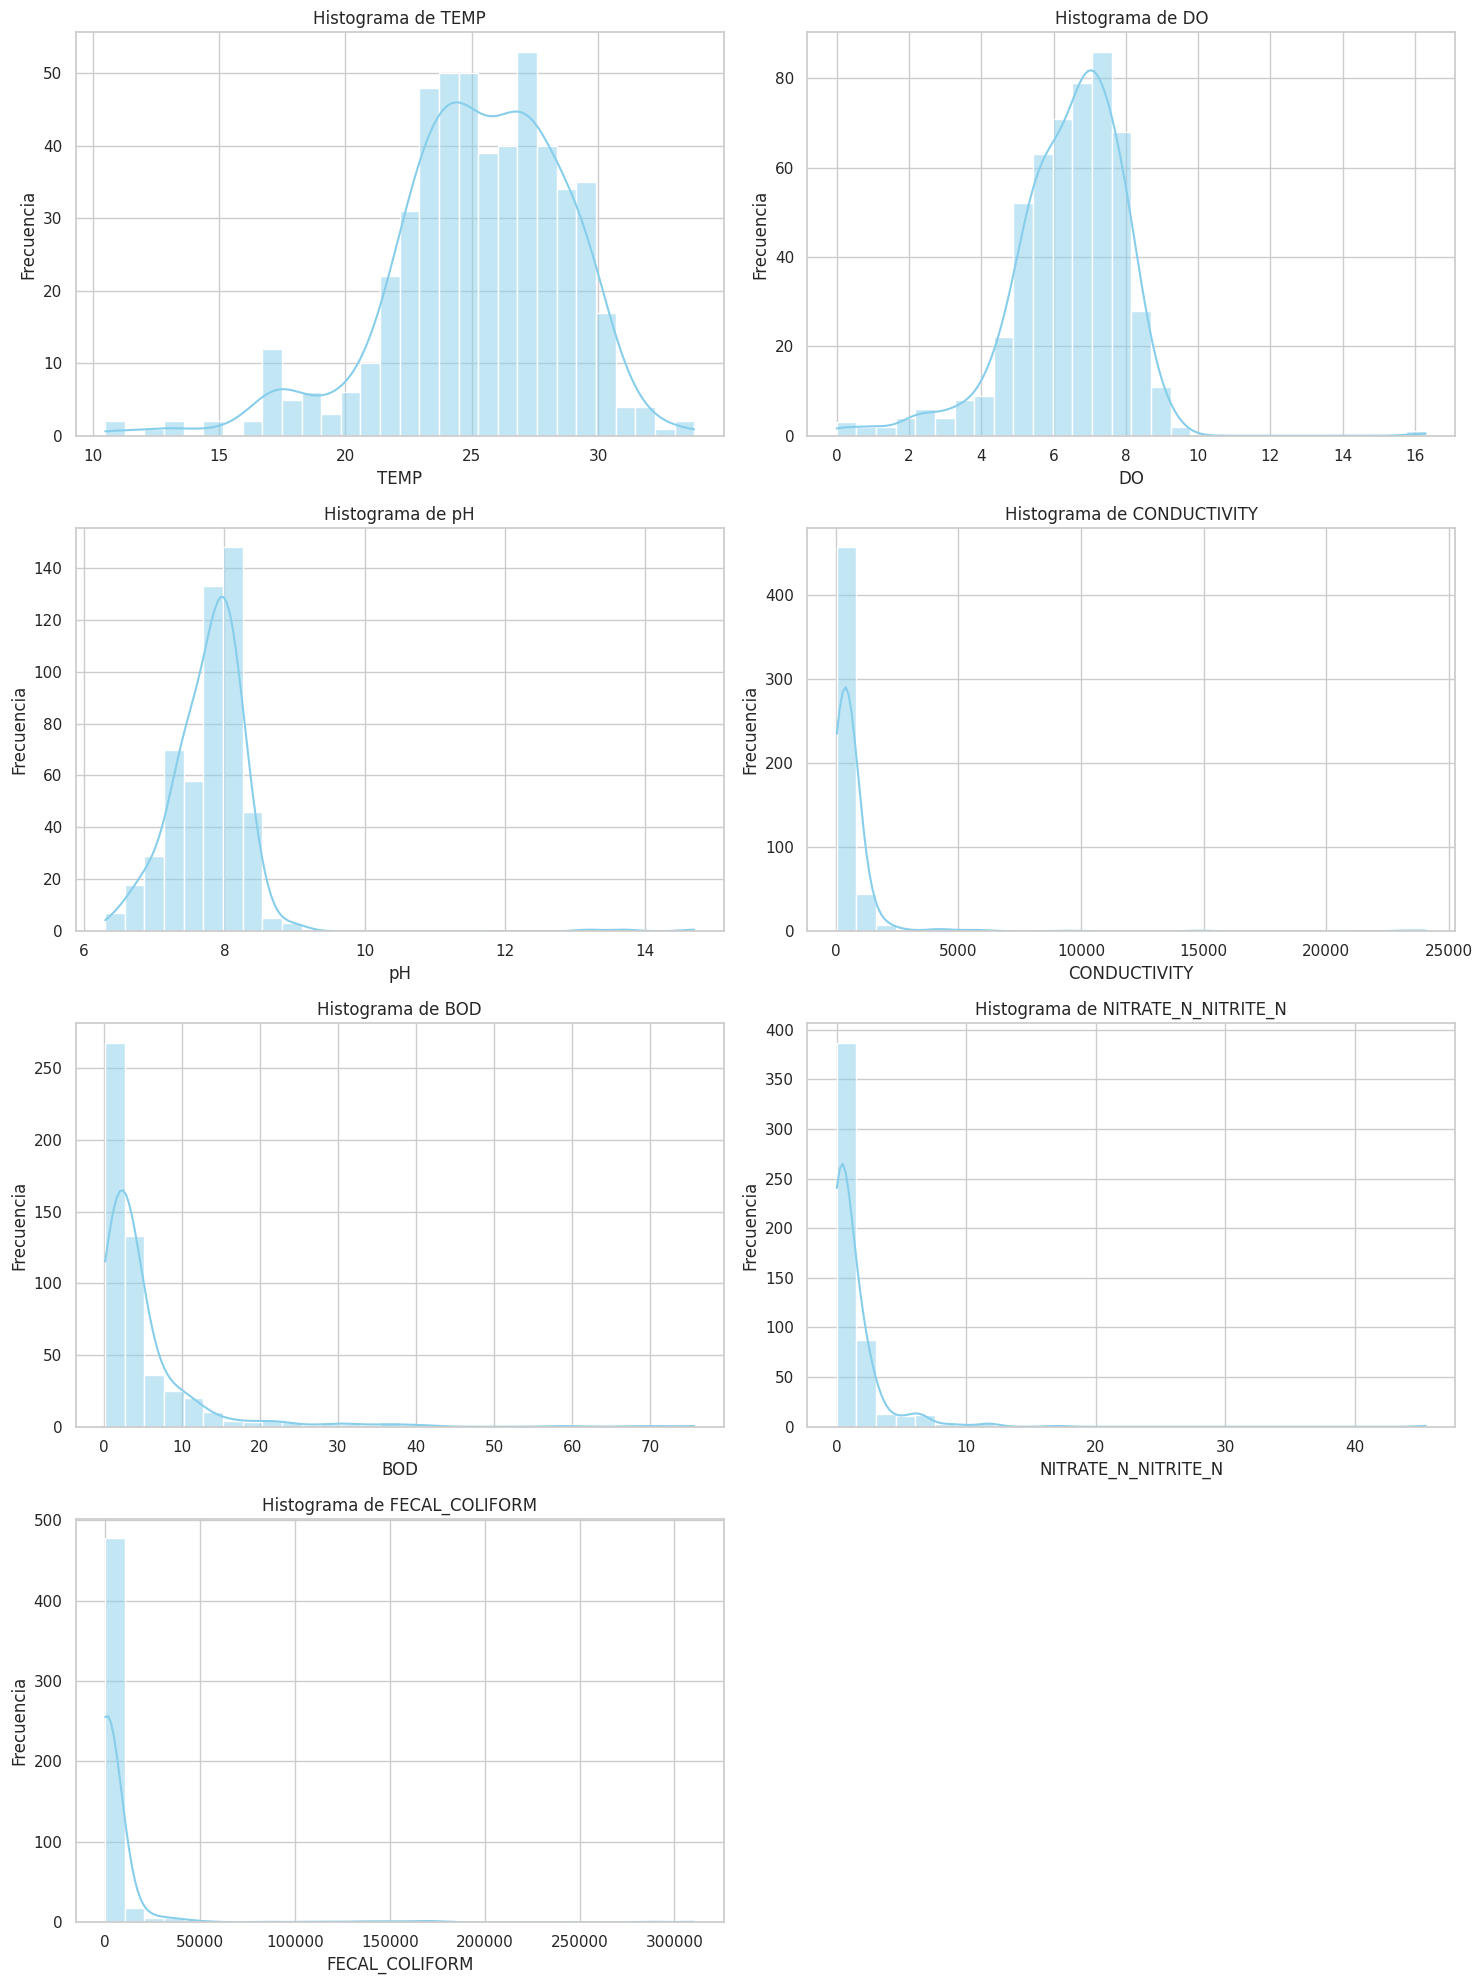

In [23]:
# Convertir solo columnas necesarias de PySpark a pandas
df_pandas = df07.select(variables).toPandas()

# Estilo visual
sns.set(style="whitegrid")
plt.figure(figsize=(15,20))

# Histogramas con FOR
for i, var in enumerate(variables, 1):
    plt.subplot(4,2,i)
    sns.histplot(df_pandas[var], bins=30, kde=True, color="skyblue")
    plt.title(f"Histograma de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

#### Observaciones:
Con el conjunto de datos limpio, se elaboraron histogramas para analizar la distribución de cada variable numérica. En general, se observa que TEMP, DO y pH presentan distribuciones más concentradas y relativamente estables. La temperatura se agrupa principalmente entre 22 y 30, el oxígeno disuelto entre 5 y 8, y el pH alrededor de valores cercanos a 7 y 8.

Por el contrario, variables como CONDUCTIVITY, BOD, NITRATE_N_NITRITE_N y FECAL_COLIFORM presentan distribuciones asimétricas hacia la derecha. Esto significa que la mayoría de los registros se concentran en valores bajos, pero existen algunos valores muy altos que alargan la cola de la distribución. Este comportamiento confirma lo observado previamente en los boxplots, donde se identificaron valores atípicos importantes.

### 3.2. Correlación entre los Parámetros

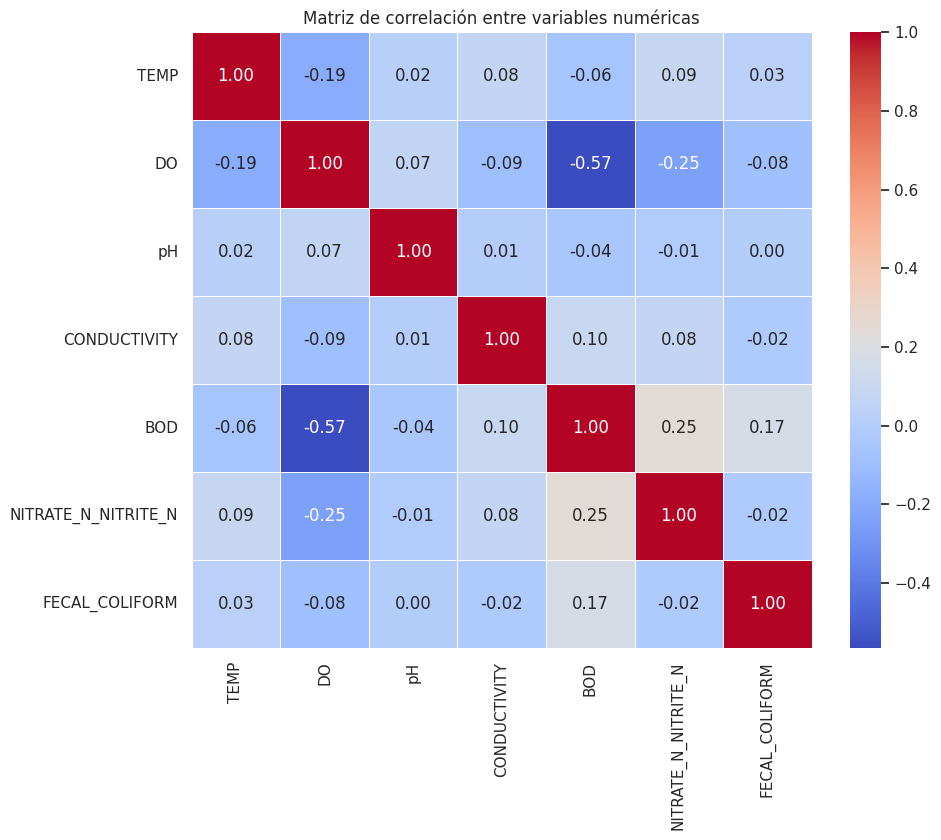

In [24]:
# Variables numéricas
variables_num = [
    "TEMP",
    "DO",
    "pH",
    "CONDUCTIVITY",
    "BOD",
    "NITRATE_N_NITRITE_N",
    "FECAL_COLIFORM"
]

# Convertir solo esas columnas a pandas
df_corr = df07.select(variables_num).toPandas()

# Calcular correlación
corr = df_corr.corr()

# Graficar mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

#### Observaciones:
La matriz de correlación muestra que, entre las variables numéricas analizadas, la relación más relevante se presenta entre la Demanda Bioquímica de Oxígeno (BOD) y el Oxígeno Disuelto (DO). El coeficiente de correlación obtenido fue -0.57, lo que indica una correlación negativa baja. En términos prácticos, esto sugiere que, a medida que aumenta la BOD, tienden a disminuir los niveles de oxígeno disuelto en el agua.

Este resultado es consistente con lo señalado por Filo 2025, donde se explica que existe una relación inversa entre ambas variables. Una mayor BOD refleja una alta presencia de materia orgánica biodegradable en el agua. Para descomponer esta materia, los microorganismos consumen mayores cantidades de oxígeno, reduciendo así la concentración de oxígeno disponible en el cuerpo de agua.

Desde una perspectiva ambiental sobre la calidad del agua, esta relación es especialmente importante, ya que niveles bajos de oxígeno disuelto pueden afectar negativamente la vida acuática. Muchas especies de peces, plantas y otros organismos requieren concentraciones mínimas de oxígeno para sobrevivir y mantener sus funciones biológicas. Por ello, valores elevados de BOD suelen considerarse un indicador de contaminación orgánica o deterioro en la calidad del agua.

Fuente:
Describe the relationship between dissolved oxygen and BOD. . . | Filo. (2025, 1 septiembre). Filo. https://askfilo.com/user-question-answers-smart-solutions/describe-the-relationship-between-dissolved-oxygen-and-bod-3337363932313533

#### Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

In [25]:
df07.createOrReplaceTempView("df01_sql")
###Se crea una consulta por cada parámetro DO
do_parametro = sparkMejia.sql("Select DO from df01_sql")
ph_parametro = sparkMejia.sql("Select pH from df01_sql")
BOD_parametro = sparkMejia.sql("Select BOD from df01_sql")
COND_parametro = sparkMejia.sql("Select CONDUCTIVITY from df01_sql")
NN_parametro = sparkMejia.sql("Select NITRATE_N_NITRITE_N from df01_sql")
FC_parametro = sparkMejia.sql("Select FECAL_COLIFORM from df01_sql")
##Se hace una consulta para crear el vector de la tabla por cada parámetro
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()
COND_parametro = COND_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()
NN_parametro = NN_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()
FC_parametro = FC_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()

### 3.3. Distribución del Oxígeno Disuelto (DO) y pH

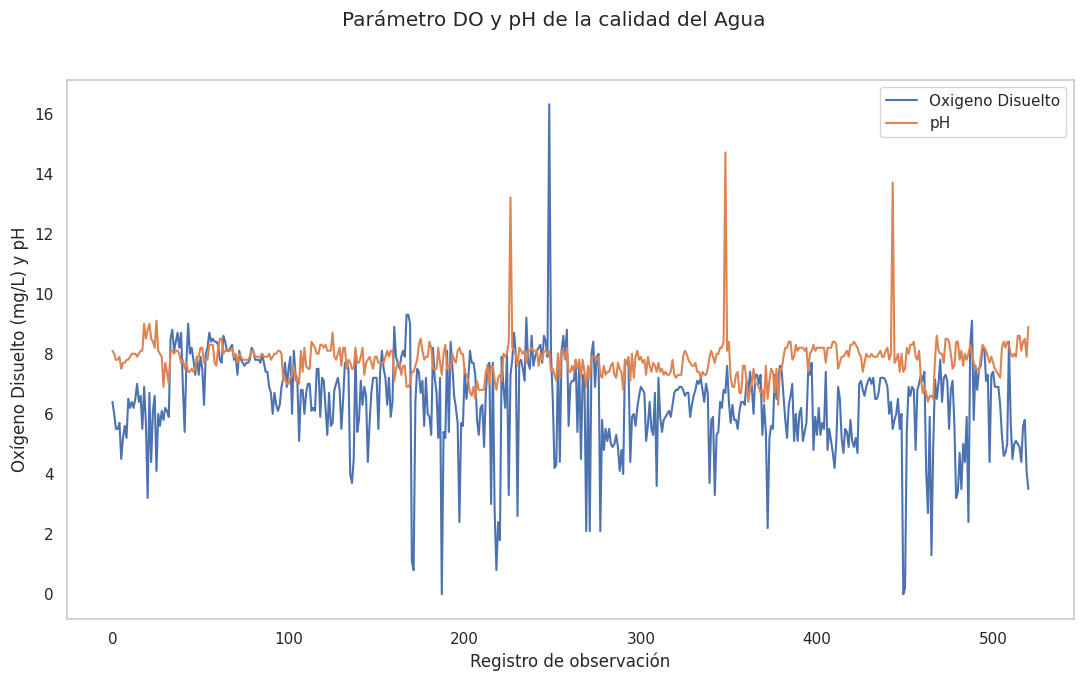

In [26]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='pH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("Registro de observación")
plt.ylabel("Oxígeno Disuelto (mg/L) y pH")
plt.grid()
plt.show()

A pesar de que anteriormente, en la matriz de correlación, no se evidencia una correlación lineal significativa entre los niveles de oxígeno disuelto (DO) y pH, ya que el coeficiente obtenido fue de 0.07, valor cercano a cero. Esto no significa que sean variables completamente independientes, sino que ambas pueden verse afectadas por factores comunes del ecosistema acuático, como la temperatura, la actividad biológica, la fotosíntesis, la contaminación orgánica y la presencia de sustancias químicas.

En cuerpos de agua con buenas condiciones ambientales, la fotosíntesis de algas y plantas acuáticas puede incrementar tanto el pH como el oxígeno disuelto (Sensor, 2026). Por el contrario, la contaminación orgánica puede disminuir el DO debido al consumo de oxígeno por parte de microorganismos y alterar el pH del agua. Esto ayuda a explicar por qué los tres valores atípicos observados en el pH, superiores a 12 (condición altamente alcalina), no presentan un mismo comportamiento en el DO. Solo uno de esos registros coincide con niveles bajos de oxígeno disuelto, lo que sugiere que esos valores extremos de pH podrían estar asociados a eventos puntuales, errores de medición o presencia de agentes externos específicos, más que a una relación constante con el oxígeno disuelto.

Fuente: Sensor, R. (2026, 9 febrero). La conexión entre los niveles de pH y la calidad del agua. https://www.rikasensor.com/es/a-the-connection-between-ph-levels-and-water-quality.html

### 3.4. Distribución de la Demanda Bioquímica de Oxígeno (BOD) y Nitrógeno

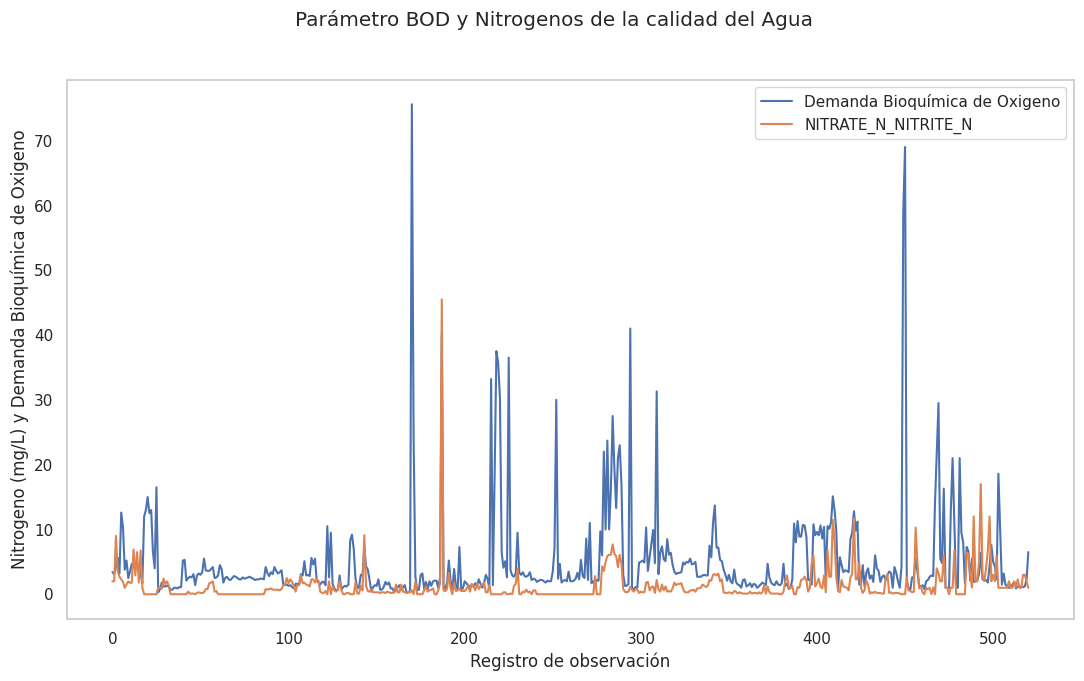

In [27]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), BOD_parametro, label='Demanda Bioquímica de Oxigeno')
ax1.plot(range(0,tam), NN_parametro, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("Registro de observación")
plt.ylabel("Nitrogeno (mg/L) y Demanda Bioquímica de Oxigeno")
plt.grid()
plt.show()

La grafica muestra que la mayoría de los registros se concentran en valores bajos, aunque ambas variables presentan varios picos atípicos a lo largo de las observaciones.
El BOD presenta una mayor variabilidad y los valores máximos más altos, lo que sugiere momentos con alta presencia de materia orgánica biodegradable. Por su parte, el nitrógeno también muestra incrementos importantes, posiblemente asociados a fertilizantes, aguas residuales o escorrentía agrícola.
La correlación entre ambas variables es de 0.25, lo que indica una relación positiva débil. Esto significa que, en algunos casos, cuando aumenta el BOD también tienden a aumentar los niveles de nitrógeno, aunque esta asociación no es fuerte ni constante en todos los registros.

### 3.5. Distribución de Coliformes Fecales (FC) y Conductividad

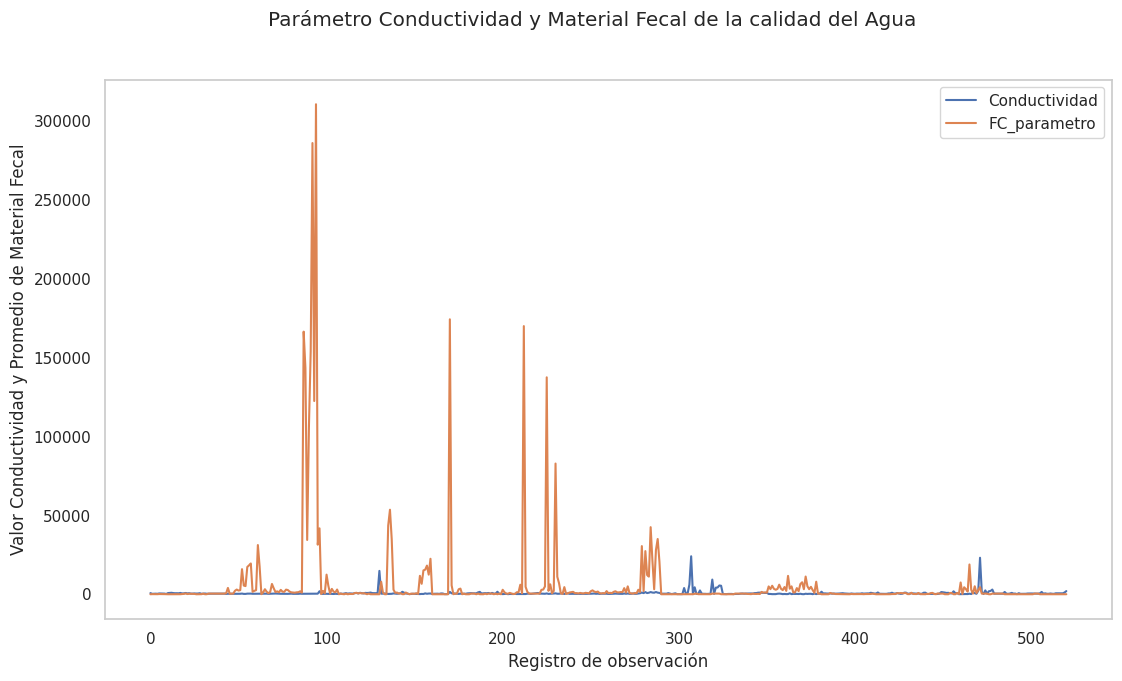

In [28]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), COND_parametro, label='Conductividad')
ax1.plot(range(0,tam), FC_parametro, label='FC_parametro')
fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')
legend=ax1.legend()
plt.xlabel("Registro de observación")
plt.ylabel("Valor Conductividad y Promedio de Material Fecal")
plt.grid()
plt.show()

Existe una alta variabilidad, especialmente en los valores de FC, donde se observan múltiples picos extremos que superan ampliamente el comportamiento normal de la serie. Esto sugiere episodios puntuales de fuerte contaminación microbiológica en determinados registros. Asimismo, la conductividad presenta un comportamiento más estable en la mayoría de observaciones, aunque también registra algunos aumentos importantes. Estos incrementos pueden estar asociados a mayor concentración de sales, minerales o sustancias disueltas en el agua.

## **4. Clasificación de la Calidad del Agua Mediante Rangos por Variable**

### 4.1. Clasificación según el pH
- #### 100: Agua Dulce
- #### 80: Agua Moderada
- #### 60: Agua Dura
- #### 40: Agua muy Dura
#### Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

El pH es un factor clave en la calidad del agua, ya que influye en su composición química, en los procesos de tratamiento y en la seguridad para el consumo. Un pH bajo (agua ácida) puede facilitar la liberación de metales como plomo, cobre o hierro desde las tuberías, aumentando riesgos para la salud. En cambio, un pH alto (agua alcalina) puede generar incrustaciones y disminuir la eficacia de la desinfección con cloro. Por ello, mantener niveles adecuados de pH es fundamental para garantizar agua segura y de buena calidad.

Fuente: Sensor, R. (2026, 9 febrero). La conexión entre los niveles de pH y la calidad del agua. https://www.rikasensor.com/es/a-the-connection-between-ph-levels-and-water-quality.html

In [29]:
df08 = df07.withColumn("qrPH", F.when((df07.pH>=7) & (df07.pH<=8.5),100).

       when(((df07.pH>=6.8) & (df07.pH<6.9)) | ((df07.pH>8.5) & (df07.pH<8.6)), 80).

       when(((df07.pH>=6.7) & (df07.pH<6.8)) | ((df07.pH>=8.6) & (df07.pH<8.8)), 60).

       when(((df07.pH>=6.5) & (df07.pH<6.7)) | ((df07.pH>=8.8) & (df07.pH<9.0)), 40).otherwise(0))

### 4.2. Clasificación según DO
- #### 100: Agua Dulce
- #### 80: Agua Moderada
- #### 60: Agua Dura
- #### 40: Agua muy Dura

A mayor DO, mejor calidad del agua. Según Ibañez, los microorganismos consumen oxígeno para degradar la materia orgánica presente en aguas residuales. Por eso, cuando hay mucha contaminación orgánica, el DO disminuye. En consecuencia, niveles bajos de oxígeno disuelto indican agua más contaminada, mientras que niveles adecuados favorecen la vida acuática y reflejan mejores condiciones ambientales.

Ibañez, C. (2025, 28 abril). Reducir la demanda biológica de oxigeno (DBO) en aguas residuales. Sigmadaf. https://sigmadafclarifiers.com/reduccion-de-la-demanda-biologica-de-oxigeno-dbo-en-las-aguas-residuales/

In [30]:
df08 = df08.withColumn("qrDO", F.when((df07.DO>=6.0), 100).
                    when((df07.DO>=5.1) & (df07.DO<6.0), 80).
                    when((df07.DO>=4.1) & (df07.DO<5.0), 60).
                    when((df07.DO>=3.0) & (df07.DO<=4.0), 40).otherwise(0))

### 4.3. Clasificación según COND
- #### 100: Agua Dulce
- #### 80: Agua Moderada
- #### 60: Agua Dura
- #### 40: Agua muy Dura

In [31]:
df08 = df08.withColumn("qrCOND", F.when(((df07.CONDUCTIVITY>=0.0) & (df07.CONDUCTIVITY<=75.0)), 100).
          when((df07.CONDUCTIVITY>75.0) & (df07.CONDUCTIVITY<=150.0), 80).
          when((df07.CONDUCTIVITY>150.0) & (df07.CONDUCTIVITY<=225.0), 60).
          when((df07.CONDUCTIVITY>225.0) & (df07.CONDUCTIVITY<=300.0), 40).otherwise(0))

### 4.4. Clasificación según BOD
- #### 100: Agua Dulce
- #### 80: Agua Moderada
- #### 60: Agua Dura
- #### 40: Agua muy Dura


"Unos niveles elevados de DBO en el agua pueden indicar la presencia de contaminantes orgánicos, que pueden provocar el agotamiento del oxígeno y tener repercusiones negativas en los ecosistemas acuáticos" (Ibañez, 2025)

Ibañez, C. (2025, 28 abril). Reducir la demanda biológica de oxigeno (DBO) en aguas residuales. Sigmadaf. https://sigmadafclarifiers.com/reduccion-de-la-demanda-biologica-de-oxigeno-dbo-en-las-aguas-residuales/

In [32]:
df08 = df08.withColumn("qrBOD", F.when(((df07.BOD>=0.0) & (df07.BOD<3.0)), 100).
                     when((df07.BOD>=3.0) & (df07.BOD<6.0), 80).
                     when((df07.BOD>=6.0) & (df07.BOD<80.0), 60).
                     when((df07.BOD>=80.0) & (df07.BOD<125.0), 40).otherwise(0))

### 4.5. Clasificación según NITRATE_N_NITRITE_N
- #### 100: Agua Dulce
- #### 80: Agua Moderada
- #### 60: Agua Dura
- #### 40: Agua muy Dura

Algunos de los problemas ambientales que son generados por la presencia de compuestos de Nitrogeno en el agua son el aumento de la acidez y el desarrollo de eutroficación. En otras palabras, altos niveles de Nitrogeno hacen que el agua no pueda ser usada para consumo humano o acuacultura.

Cárdenas Calvachi, Gloria Lucia, & Sánchez Ortiz, Iván Andrés. (2013). Nitrógeno en aguas residuales: orígenes, efectos y mecanismos de remoción para preservar el ambiente y la salud pública. Universidad y Salud, 15(1), 72-88. Retrieved April 27, 2026, from http://www.scielo.org.co/scielo.php?script=sci_arttext&pid=S0124-71072013000100007&lng=en&tlng=es.

In [33]:
df08 = df08.withColumn("qrNN", F.when(((df07.NITRATE_N_NITRITE_N>=0.0) & (df07.NITRATE_N_NITRITE_N<20.0)), 100).
                     when((df07.NITRATE_N_NITRITE_N>=20.0) & (df07.NITRATE_N_NITRITE_N<50.0), 80).
                     when((df07.NITRATE_N_NITRITE_N>=50.0) & (df07.NITRATE_N_NITRITE_N<100.0), 60).
                     when((df07.NITRATE_N_NITRITE_N>=100.0) & (df07.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

### 4.6. Clasificación según el Material Fecal
- #### 100: Agua Dulce
- #### 80: Agua Moderada
- #### 60: Agua Dura
- #### 40: Agua muy Dura

In [34]:
df08 = df08.withColumn("qrFecal", F.when(((df07.FECAL_COLIFORM>=0.0) & (df07.FECAL_COLIFORM<5.0)), 100).
                    when((df07.FECAL_COLIFORM>=5.0) & (df07.FECAL_COLIFORM<50.0), 80).
                    when((df07.FECAL_COLIFORM>=50.0) & (df07.FECAL_COLIFORM<500.0), 60).
                    when((df07.FECAL_COLIFORM>=500.0) & (df07.FECAL_COLIFORM<1000.0), 40).otherwise(0))

## **5. Construcción del Índice de Calidad del Agua (ICA)**
#### El objeto dataframe df08, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua. A continuación se hace una inspección en general del df08

### 5.1. Verificación del DataFrame Base (df08)

In [35]:
df08.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION_CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

In [36]:
df08.columns

['STATION_CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

### 5.2. Creación de Variables de Puntaje por Parámetro

#### Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

In [37]:
df09 = df08.withColumn("wpH", F.round(df08.qrPH*0.165,3))
df09 = df09.withColumn("wDO", F.round(df09.qrDO*0.281,3))
df09 = df09.withColumn("wCOND", F.round(df09.qrCOND*0.234,3))
df09 = df09.withColumn("wBOD", F.round(df09.qrBOD*0.009,3))
df09 = df09.withColumn("wNN", F.round(df09.qrNN*0.028,3))
df09 = df09.withColumn("wFecal", F.round(df09.qrFecal*0.281,3))

In [38]:
df09.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION_CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

In [39]:
df09.columns

['STATION_CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### 5.3. Cálculo del Índice Global de Calidad del Agua
#### Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

In [40]:
df10 = df09.withColumn("WQI", F.round(df09.wpH+df09.wBOD+df09.wCOND+df09.wNN+df09.wFecal+df09.wDO,3))
df10.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION_CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

### 5.4. Clasificación Final del Agua según ICA

**Intervalos de Índices para WQI**

- Excelente: agua dulce ***WQI = [0.0 , 25.0]***
- Buena: agua moderada ***WQI = (25.0 , 50.0]***
- Baja: agua dura ***WQI = (50.0 , 75.0]***
- Muy_Baja: agua muy dura ***WQI = (75.0 , 100.0]***
- Inadecuada: agua residual ***WQI > 100***

In [41]:
df11 = df10.withColumn("CALIDAD", F.when((df10.WQI>=0) & (df10.WQI<25),'Excelente')
    .when((df10.WQI>=25) & (df10.WQI<50),'Buena')
    .when((df10.WQI>=50) & (df10.WQI<75),'Baja')
    .when((df10.WQI>=75) & (df10.WQI<100),'Muy_Baja')
    .otherwise('Inadecuada')
                      )
df11.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION_CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### **6. Visualización de Estados de la India**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua




In [42]:
#Impresión de nombre de regiones sobre el mapa
colEstado = 'STATE'
valNomnbres = df11.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)


['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### 6.1. Se cargan los datos de los mapas disponibles

In [43]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [44]:
##Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta
import geopandas as gpd
rutaMapas = "Indian_States.zip"

### 6.2. Se carga un objeto dataframe de los datos comprimidos de los mapas

In [45]:
gpd01 = gpd.read_file(rutaMapas)

### 6.3. Se visualiza el tipo de dataframe que da geopandas y las columnas 

In [46]:
print(type(gpd01))
gpd01.columns

<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

In [47]:
#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

array(['Andaman & Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara & Nagar Havelli',
       'Daman & Diu', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
       'Meghalaya', 'Mizoram', 'Nagaland', 'NCT of Delhi', 'Puducherry',
       'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana',
       'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Odisha',
       'Andhra Pradesh'], dtype=object)

### 6.4. Corrección nombres 
#### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan con los nombres de los estados del dataframe de datos inicial

In [48]:
gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                     'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                     'Daman & Diu': 'Daman Diu', 
                     'Jammu & Kashmir': 'Jammu Kashmir',
                     'NCT of Delhi' : 'Delhi'
                      })
gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [49]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df12 = df11.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df12 = df12.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df12.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION_CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [50]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df12.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### 6.5. Mapa inicial

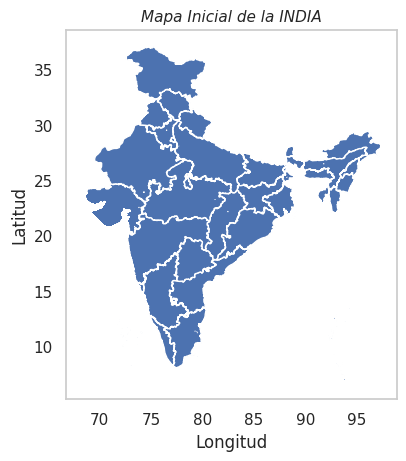

In [51]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()

#### *Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [52]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


### 6.6. Mapa del Indice de Calidad WQI de la India

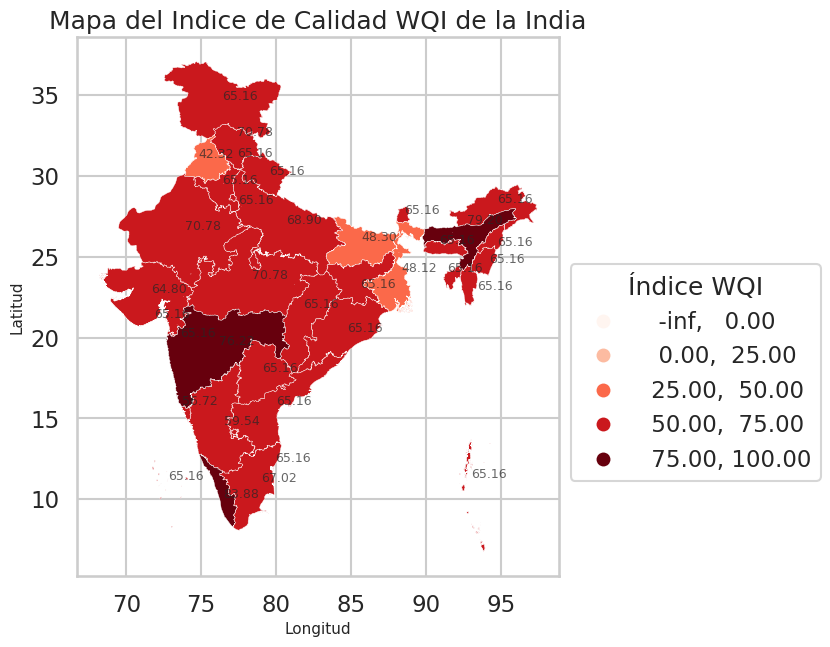

In [ ]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].mean())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

### 6.7. Histograma de WQI por Estado

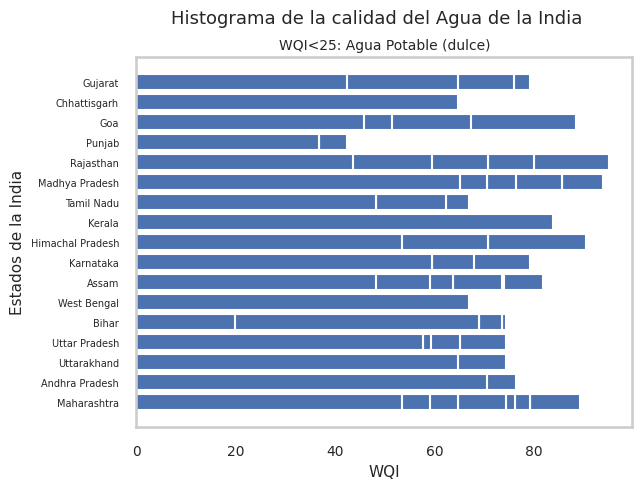

In [54]:
df12.createOrReplaceTempView("df12_sql")
#Se seleccionan los nombres de los estados
Estados = sparkMejia.sql("Select STATE from df12_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkMejia.sql("Select WQI from df12_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

# Analisis

## **7. Predicción del Índice de Calidad del Agua mediante Redes Neuronales**

    - Se requiere predecir el parámetro WQI
    - Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
    - Se importa Scikit-Learn, para separar los datos (Entrenamiento y Prueba)
    - Se importa Keras Sequential Layers Dense
    - Se inicializa el modelo, y se añaden las capas
    - Se compila el modelo con el optimizador ADAM junto con la función de perdida de error cuadrático
    - Se realiza el experimento sobre los datos de entrenamiento
    - Se realiza la evaluación sobre los datos de prueba; para la selección del modelo.

In [55]:
df12.columns

['STATION_CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

### 7.1. Preparación de Datos para el Modelo
En esta etapa se seleccionaron las variables predictoras asociadas a los rangos de calidad del agua (qrPH, qrDO, qrCOND, qrBOD, qrNN y qrFecal), las cuales representan la clasificación individual de cada parámetro analizado. Como variable objetivo se definió el índice global de calidad del agua (WQI).

Posteriormente, los datos fueron convertidos a formato Pandas para facilitar su manipulación con Scikit-Learn y TensorFlow. Finalmente, el conjunto de datos se dividió en entrenamiento (80%) y prueba (20%), con el fin de entrenar el modelo sobre una parte de la información y evaluar su capacidad predictiva sobre datos no vistos previamente.

In [56]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df12.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df12.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



In [57]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [58]:
print(f"Cantidad de datos totales: {df12.count(), len(df12.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (521, 24)
Cantidad de datos Entrenamiento: (416, 6)
Cantidad de datos Prueba: (105, 6)
Cantidad de datos Predicción del Entrenamiento: (416, 1)
Cantidad de datos Predicción de Prueba: (105, 1)


In [59]:
#En caso de que sea necesario instalarlo
!pip install keras

Defaulting to user installation because normal site-packages is not writeable


In [60]:
#En caso de que sea necesario instalarlo
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [61]:
## Se importa la instancia TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

2026-04-27 18:12:21.709582: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 18:12:21.854191: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 18:12:24.179991: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 7.2. Construcción de la Red Neuronal
En esta fase se diseñó una red neuronal secuencial orientada a la predicción del índice de calidad del agua (WQI). La arquitectura del modelo se compuso de una capa de entrada con seis variables predictoras y varias capas ocultas densamente conectadas de 350 neuronas cada una, utilizando la función de activación ReLU, la cual permite modelar relaciones no lineales entre las variables.

Finalmente, se incorporó una capa de salida con una sola neurona y activación lineal, adecuada para problemas de regresión donde se busca estimar un valor numérico continuo. Adicionalmente, se definieron parámetros iniciales de entrenamiento, como el número de épocas y el tamaño de lote, que controlan el proceso de aprendizaje del modelo.

In [62]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200 #Las épocas son la cantidad de veces que el modelo verá todo el conjunto de entrenamiento.
lote = 81 #grupos pequeños
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-27 18:12:24.439674: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### 7.3. Compilación y Entrenamiento del Modelo

Se compiló la red neuronal utilizando el optimizador Adam con tasa de aprendizaje de 0.001, debido a su eficiencia y estabilidad en problemas de regresión. Como función de pérdida se empleó el error cuadrático medio (MSE), apropiado para la predicción del índice WQI como variable continua.

In [63]:
#Para optimizar el modelo se usa el optimizador ADAM
#La compilación se ajusta a la pérdida del error cuadrático
tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, amsgrad=False)
modelo01.compile(loss='mean_squared_error', optimizer='Adam', metrics=['mse'])

In [64]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

Posteriormente, se inició el entrenamiento del modelo empleando los datos del conjunto de entrenamiento. El proceso se desarrolló durante un 200 épocas y mediante 81 lotes de observaciones, permitiendo que la red neuronal actualizara iterativamente sus parámetros internos hasta mejorar su capacidad predictiva. El modelo final contó con 248,501 parámetros entrenables, reflejando una estructura con alta capacidad de aprendizaje para capturar patrones complejos en los datos.

In [65]:
ejecutarK = modelo01.fit(dataTrain, predTrain, epochs=epocas, batch_size=lote)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2199.2209 - mse: 2199.2209
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 171.4107 - mse: 171.4107
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 74.6537 - mse: 74.6537
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 40.3153 - mse: 40.3153
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 28.5744 - mse: 28.5744
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 13.6227 - mse: 13.6227
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 6.6176 - mse: 6.6176
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.4247 - mse: 2.4247
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.6114 - mse: 1.6114 
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8639 - mse: 0.8639
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4961 - mse: 0.4961
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4097 - mse: 0.4097
Epoch 13/200
6/6 ━━━━━━━━━━━━━

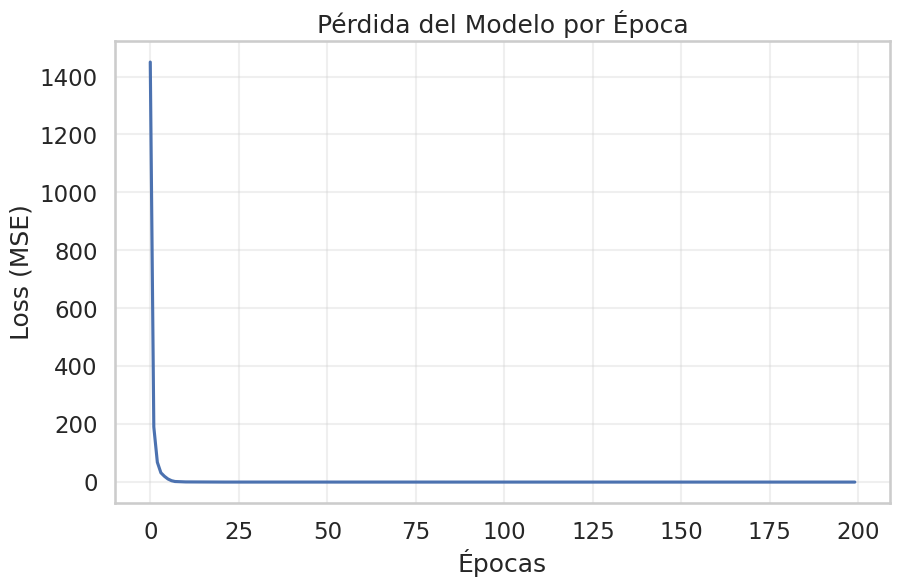

In [66]:
plt.figure(figsize=(10,6))
plt.plot(ejecutarK.history['loss'])
plt.title('Pérdida del Modelo por Época')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.grid(True, alpha=0.3)
plt.show()

#### Observaciones:
El modelo fue entrenado mediante la función fit(), utilizando los datos de entrenamiento como variables predictoras y el WQI como variable objetivo.
La función de pérdida mostró una disminución pronunciada durante las primeras épocas, pasando de valores altos iniciales a valores cercanos a cero. Esto evidencia que la red neuronal logró aprender rápidamente la relación entre las variables fisicoquímicas y el índice WQI. Sin embargo, se recomienda contrastar estos resultados con el conjunto de prueba para descartar sobreajuste.

### 7.4. Evaluación del Modelo Predictivo
#### Para medir el desempeño de la red neuronal se utilizaron tres métricas ampliamente empleadas en problemas de regresión: RMSE, MAE y R². Estas permiten cuantificar qué tan cercanas son las predicciones generadas por el modelo respecto a los valores reales del índice de calidad del agua (WQI).

In [67]:
# prediccion sobre los datos del entrenamiento
# Corresponde al conjunto de datos utilizado para enseñar al modelo durante el proceso de aprendizaje. 
# Con estos datos la red neuronal ajusta sus pesos internos y aprende patrones.
predModelo01_Train = modelo01.predict(dataTrain)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [68]:
# Predicción prueba
# Es un conjunto de datos separado que no fue utilizado durante el entrenamiento. 
# Se emplea para evaluar la capacidad del modelo de generalizar y realizar buenas predicciones sobre datos nuevos.
predModelo01_Test = modelo01.predict(dataTest)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


Para evaluar el desempeño del modelo predictivo se compararon los resultados obtenidos en el conjunto de entrenamiento y en el conjunto de prueba. Esta comparación permite identificar si el modelo presenta sobreajuste, es decir, si aprende muy bien los datos de entrenamiento, pero pierde capacidad de generalización frente a datos nuevos.

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Convertir a vector
predModelo01_Train = predModelo01_Train.flatten()
predModelo01_Test  = predModelo01_Test.flatten()

# ------------------------------------------
# Métricas entrenamiento
# ------------------------------------------

rmse_train = np.sqrt(mean_squared_error(predTrain, predModelo01_Train))
mae_train  = mean_absolute_error(predTrain, predModelo01_Train)
r2_train   = r2_score(predTrain, predModelo01_Train)

# ------------------------------------------
# Métricas prueba
# ------------------------------------------

rmse_test = np.sqrt(mean_squared_error(predTest, predModelo01_Test))
mae_test  = mean_absolute_error(predTest, predModelo01_Test)
r2_test   = r2_score(predTest, predModelo01_Test)

# ------------------------------------------
# Tabla resumen
# ------------------------------------------

resultados = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "RMSE": [rmse_train, rmse_test],
    "MAE": [mae_train, mae_test],
    "R2": [r2_train, r2_test]
})

print(resultados)

  Dataset      RMSE       MAE        R2
0   Train  0.026397  0.018062  0.999996
1    Test  0.301797  0.066598  0.999541


#### RMSE (Root Mean Squared Error): 
Raíz del error cuadrático medio. Mide la magnitud promedio del error entre valores reales y predichos, penalizando con mayor intensidad los errores grandes. Valores más cercanos a cero indican mejor desempeño del modelo.
#### MAE (Mean Absolute Error):
Error absoluto medio. Calcula la diferencia promedio, en valor absoluto, entre las predicciones y los valores reales. Su interpretación es más directa que RMSE, ya que expresa cuánto se equivoca el modelo en promedio.
#### R² (Coeficiente de Determinación):
Indica la proporción de la variabilidad de la variable objetivo que es explicada por el modelo. Sus valores suelen oscilar entre 0 y 1, donde valores cercanos a 1 representan un ajuste excelente y una alta capacidad explicativa.
#### Observaciones:
Los resultados muestran que el modelo tuvo un desempeño alto tanto en entrenamiento como en prueba. En el conjunto de prueba obtuvo un RMSE de 0.323 y un MAE de 0.084. Aunque estos valores son mayores en el conjunto de prueba, el valor de R² se mantiene muy cercano a 1 en ambos casos, indicando errores mínimos y una capacidad explicativa cercana al 100%. Esto evidencia una alta precisión en la estimación del índice WQI. Entonces el modelo conserva una buena capacidad predictiva sobre datos no usados en el entrenamiento, por lo que no se observa un sobreajuste fuerte.

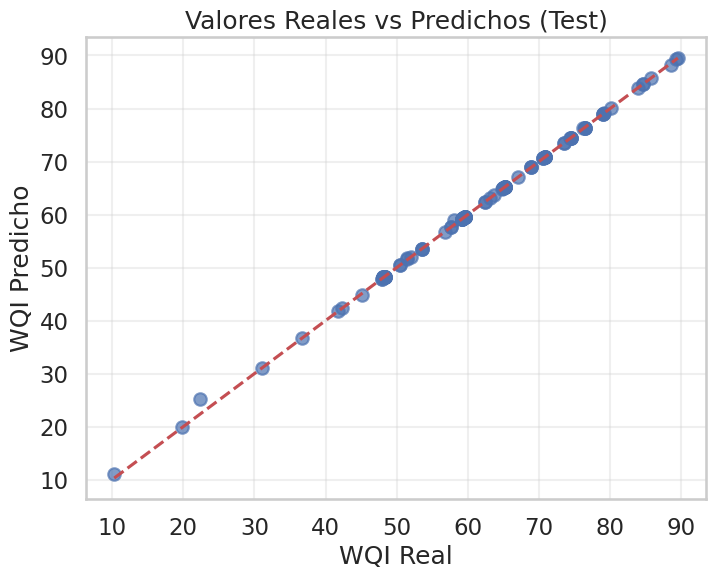

In [70]:
# Convertir reales y predichos a vectores numéricos
y_test_real = pd.to_numeric(np.array(predTest).ravel(), errors='coerce')
y_test_pred = pd.to_numeric(np.array(predModelo01_Test).ravel(), errors='coerce')

# Quitar valores NaN si aparecen
mask = ~np.isnan(y_test_real) & ~np.isnan(y_test_pred)

y_test_real = y_test_real[mask]
y_test_pred = y_test_pred[mask]

# Gráfico Real vs Predicho
plt.figure(figsize=(8,6))
plt.scatter(y_test_real, y_test_pred, alpha=0.7)

plt.xlabel("WQI Real")
plt.ylabel("WQI Predicho")
plt.title("Valores Reales vs Predichos (Test)")

# Línea ideal
min_val = min(y_test_real.min(), y_test_pred.min())
max_val = max(y_test_real.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.grid(True, alpha=0.3)
plt.show()

La gráfica de valores reales versus predichos muestra que la mayoría de observaciones se ubican sobre la diagonal de referencia, indicando una alta concordancia entre los valores reales de WQI y los estimados por la red neuronal. Esto evidencia un excelente desempeño predictivo del modelo en el conjunto de prueba.

#### Conclusion:

En resumen, después de realizar el proceso de limpieza de datos, fue posible trabajar con un dataset sin valores nulos para continuar con el análisis exploratorio de los parámetros. Allí se encontró una correlación débil negativa entre la Demanda Bioquímica de Oxígeno (BOD) y el Oxígeno Disuelto (DO), lo que indica que cuando una de estas variables aumenta, la otra disminuye. Luego, se realizó la clasificación de la calidad del agua mediante rangos por variable, para finalmente construir el Índice de Calidad del Agua.

A partir del Índice de Calidad del Agua se pudo observar que los diferentes estados de la India presentan condiciones precarias. De hecho, con base en el indicador 6.3.2 de los ODS, solo el 10% de las masas de agua monitoreadas en India tiene buena calidad (India | Datos del ODS 6, 2023). El análisis realizado sustenta esta afirmación, ya que son pocos los estados donde la calidad del agua promedio es menor a 25 (agua dulce).

Finalmente, se aplicaron técnicas de machine learning con PySpark mediante el entrenamiento de un modelo de red neuronal. Tras el proceso de entrenamiento, se realizó la prueba de predicción y se obtuvieron valores muy cercanos a los reales; al evaluar el modelo con las métricas RMSE, MAE y R², los resultados fueron favorables.

Se sugiere tomar en cuenta este análisis para predecir los valores de calidad del agua en diferentes lugares y poder realizar acciones preventivas o correctivas, porque el agua es un derecho, no un lujo.

India | Datos del ODS 6.3.2. (2023). https://www.sdg6data.org/es/country-or-area/India